# Cross-datase

## Load libraries

In [1]:
# Data librarie
import pandas as pd
import anndata as ad
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & statistics
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency

# Load trained modal
import joblib

## Load data

In [2]:
source = "ec_obj_imputed_log2.h5ad"
ec_data = ad.read_h5ad(source)
cell_metadata = ec_data.obs

In [3]:
ec_snr_data = pd.read_csv("master_detailed_comment.csv")

## Load trained model

In [4]:
clf = joblib.load("proj_cluster_clf.pkl")

## Predict projection clusters for MERFISH cells

In [5]:
# Standardize MERFISH spatial coordinates
coor_supertype = StandardScaler().fit_transform(cell_metadata[["x_ccf", "y_ccf", "z_ccf"]])

# Predict projection cluster labels from spatial coordinates
pred_proj_cluster = clf.predict(coor_supertype)


df = cell_metadata.copy()
df["pred_proj_cluster"] = pred_proj_cluster

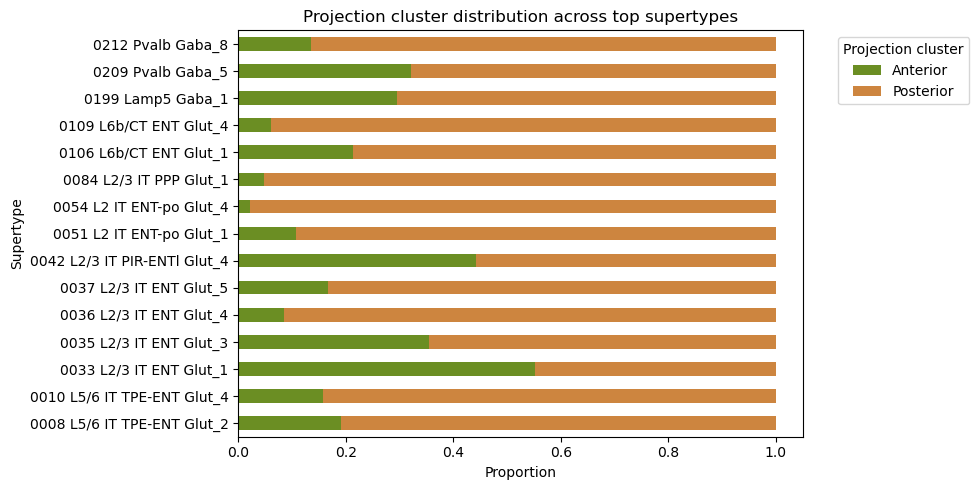

In [6]:
# Identify the most 15 frequent supertypes
top_supertypes = df["supertype"].value_counts().head(15).index

df_top = df[df["supertype"].isin(top_supertypes)].copy()

# Contingency table for top15 supertypes
ct_top15 = pd.crosstab(df_top["supertype"], df_top["pred_proj_cluster"])

# Convert counts to proportions
ct_top15_prop = ct_top15.div(ct_top15.sum(axis=1), axis=0)

ct_top15_prop = ct_top15_prop.sort_index()

# Plot stacked bar chart showing projection cluster composition
ax = ct_top15_prop.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 5),
    color=["olivedrab","peru"]
)

plt.xlabel("Proportion")
plt.ylabel("Supertype")
plt.title("Projection cluster distribution across top supertypes")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    title="Projection cluster"
)

plt.tight_layout()
plt.show()

In [7]:
# Contingency table for all supertypes
ct = pd.crosstab(df["supertype"], df["pred_proj_cluster"])

## Chech the association between supertype and predicted projection cluster

In [8]:
# Perform chi-square test
chi, p, dof, ex = chi2_contingency(ct)

n = ct.sum().sum()

# Degrees of freedom adjustment for Cramér's V
k = min(ct.shape) - 1

# Calculate Cramér's V
cramers_v = np.sqrt(chi / (n * k))

print("Cramér's V:", cramers_v)

Cramér's V: 0.43572176488317516


In [9]:
# extract 4 selected supertypes
st0008 = df[
    df["supertype"].str.contains("0008 L5/6 IT TPE-ENT Glut_", na=False)
].copy()
st0007 = df[
    df["supertype"].str.contains("0007 L5/6 IT TPE-ENT Glut_", na=False)
].copy()
st0010 = df[
    df["supertype"].str.contains("0010 L5/6 IT TPE-ENT Glut_", na=False)
].copy()
st0129np = df[
    df["supertype"].str.contains("0129 NP PPP Glut_", na=False)
].copy()


In [10]:
# compute groups
gp = {
    "0008 L5/6 IT TPE-ENT Glut": st0008,
    "0007 L5/6 IT TPE-ENT Glut": st0007,
    "0010 L5/6 IT TPE-ENT Glut": st0010,
    "0129 NP PPP Glut": st0129np
}

## Visiualise projection cluster distributions of the four selected supertypes

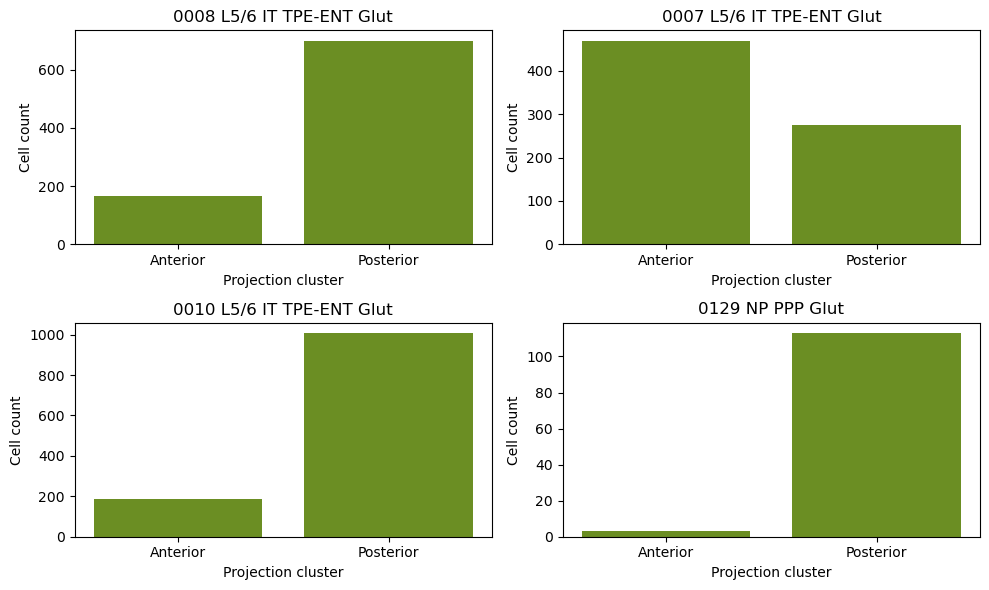

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10,6))
axes = axes.flatten()

for ax, (name, subdf) in zip(axes, gp.items()):
    
     # Count cells assigned to each predicted projection cluster
    counts = subdf["pred_proj_cluster"].value_counts()
    
    # Ensure both clusters are displayed
    counts = counts.reindex(["Anterior", "Posterior"], fill_value=0)

    ax.bar(counts.index, counts.values, color="olivedrab")

    ax.set_title(name)
    ax.set_xlabel("Projection cluster")
    ax.set_ylabel("Cell count")

plt.tight_layout()
plt.show()